In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

In [2]:
df = yf.download("AAPL", start="2018-01-01", end="2024-01-01")
data = df[['Close']].values

scaler = MinMaxScaler()
data = scaler.fit_transform(data)

window = 30
X, y = [], []

for i in range(window, len(data)):
    X.append(data[i-window:i])
    y.append(data[i])

X = np.array(X)
y = np.array(y)

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

[*********************100%***********************]  1 of 1 completed


In [3]:
model = Sequential([
    SimpleRNN(64, input_shape=(window,1)),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

early = EarlyStopping(patience=5, restore_best_weights=True)
tb_callback = TensorBoard(log_dir="runs/stock_rnn", histogram_freq=1)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early, tb_callback]
)

c:\Program Files\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0455 - val_loss: 0.0033
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5390e-04 - val_loss: 0.0010
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0656e-04 - val_loss: 0.0010
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7650e-04 - val_loss: 9.3002e-04
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5146e-04 - val_loss: 8.3801e-04
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3651e-04 - val_loss: 8.1947e-04
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0900e-04 - val_loss: 8.3040e-04
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0012e-04 - val_loss: 9.1213e-04
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.2098e-04 - val_loss: 7.3638e-04
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8387e-04 - val_loss: 7.2940e-04
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6519e-04 - val_loss: 6.8785e-04
E

In [4]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_test_real = scaler.inverse_transform(y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [5]:
rmse = np.sqrt(mean_squared_error(y_test_real,pred))
mae = mean_absolute_error(y_test_real,pred)

mape = np.mean(np.abs((y_test_real - pred)/y_test_real))*100
r2 = r2_score(y_test_real,pred)

print("RMSE:",rmse)
print("MAE:",mae)
print("MAPE:",mape)
print("R2:",r2)

RMSE: 3.5050752813095327
MAE: 2.8844163997753256
MAPE: 1.7281497302802447
R2: 0.967567422824324


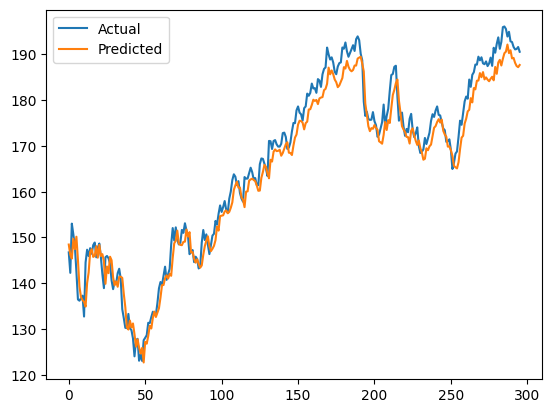

In [6]:
plt.plot(y_test_real,label="Actual")
plt.plot(pred,label="Predicted")
plt.legend()
plt.show()